## Model for CNN

In [1]:
from keras import Model, Input
from keras.layers import Conv2D, MaxPool2D, Rescaling, Dense, Flatten

In [2]:
def cnn_model(inputShape=(224, 224, 3), numClasses=10):
    inputs = Input(shape=inputShape)

    x = Rescaling(1.0 / 255)(inputs)

    # BODY (Feature Extractor)
    # -------------------------------
    # Conv Block 1: 32-32-MaxPool.
    # -------------------------------
    x = Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # -------------------------------
    # Conv Block 2: 64-64-MaxPool.
    # -------------------------------
    x = Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # -------------------------------
    # Conv Block 3: 128-128-MaxPool.
    # -------------------------------
    x = Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # -------------------------------
    # Conv Block 3: 256-256-MaxPool.
    # -------------------------------
    x = Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # Head
    # -------------------------------
    # Fully conneted layers.
    # -------------------------------
    x = Flatten()(x)

    x = Dense(512, activation="relu")(x)
    outputs = Dense(numClasses, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model

Classnames: 
0 baseball
1 basketball
2 beachballs
3 billiard ball
4 bowling ball
5 brass
6 buckeyballs
7 cannon ball
8 cricket ball
9 eyeballs


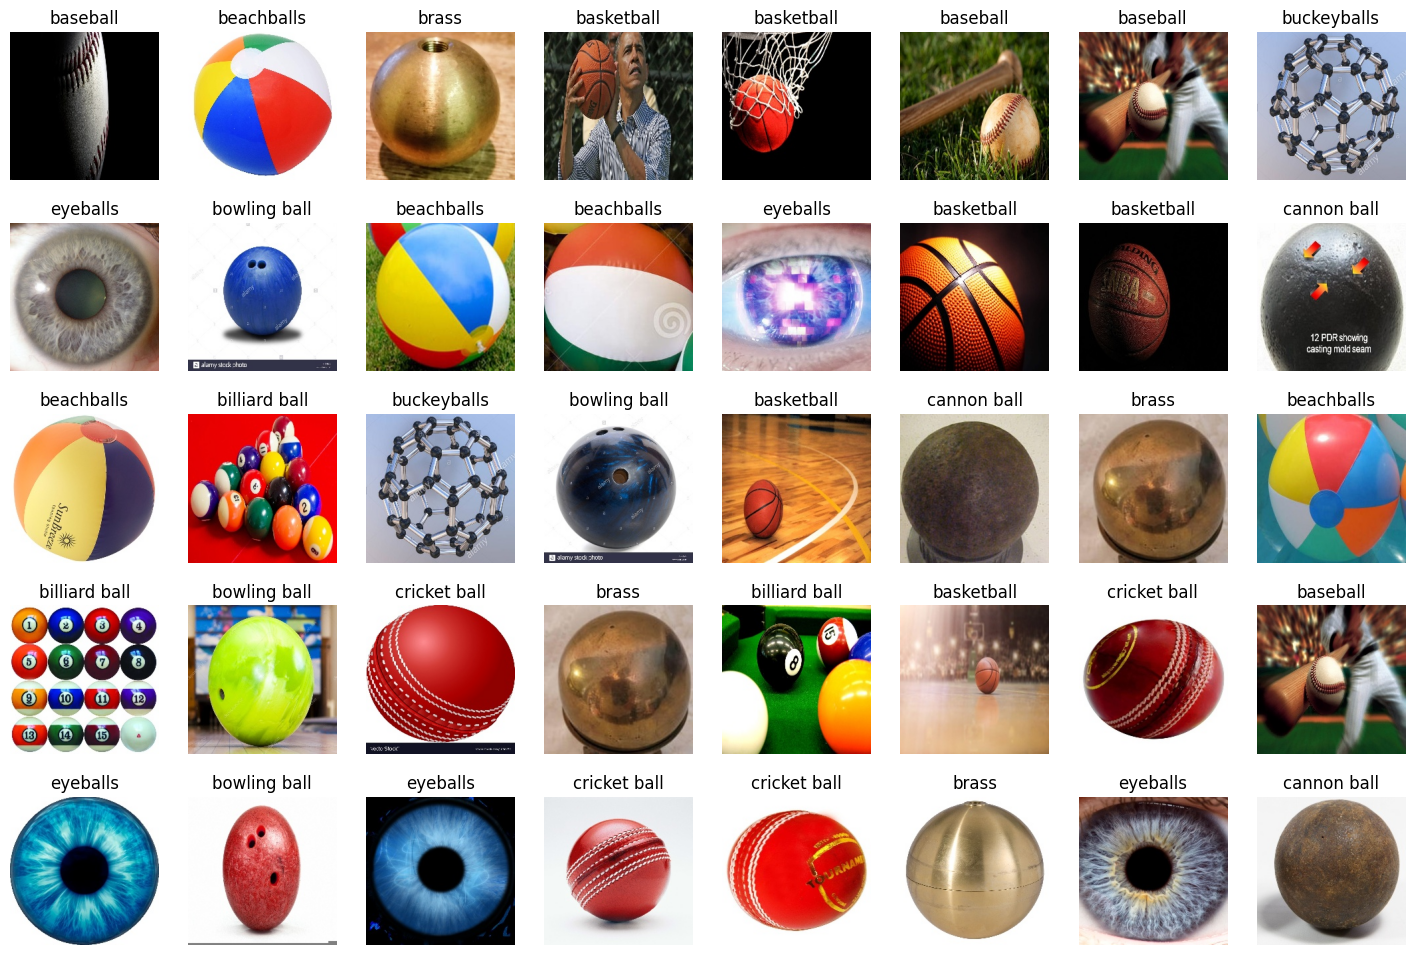

Found 1125 files belonging to 10 classes.
Found 200 files belonging to 10 classes.
Data batch shape: (64, 224, 224, 3)
Labels batch shape: (64, 10)
Take() Data batch shape: (64, 224, 224, 3)
Take() Labels batch shape: (64, 10)
['baseball', 'basketball', 'beachballs', 'billiard ball', 'bowling ball', 'brass', 'buckeyballs', 'cannon ball', 'cricket ball', 'eyeballs']


2025-11-27 14:53:51.563699: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


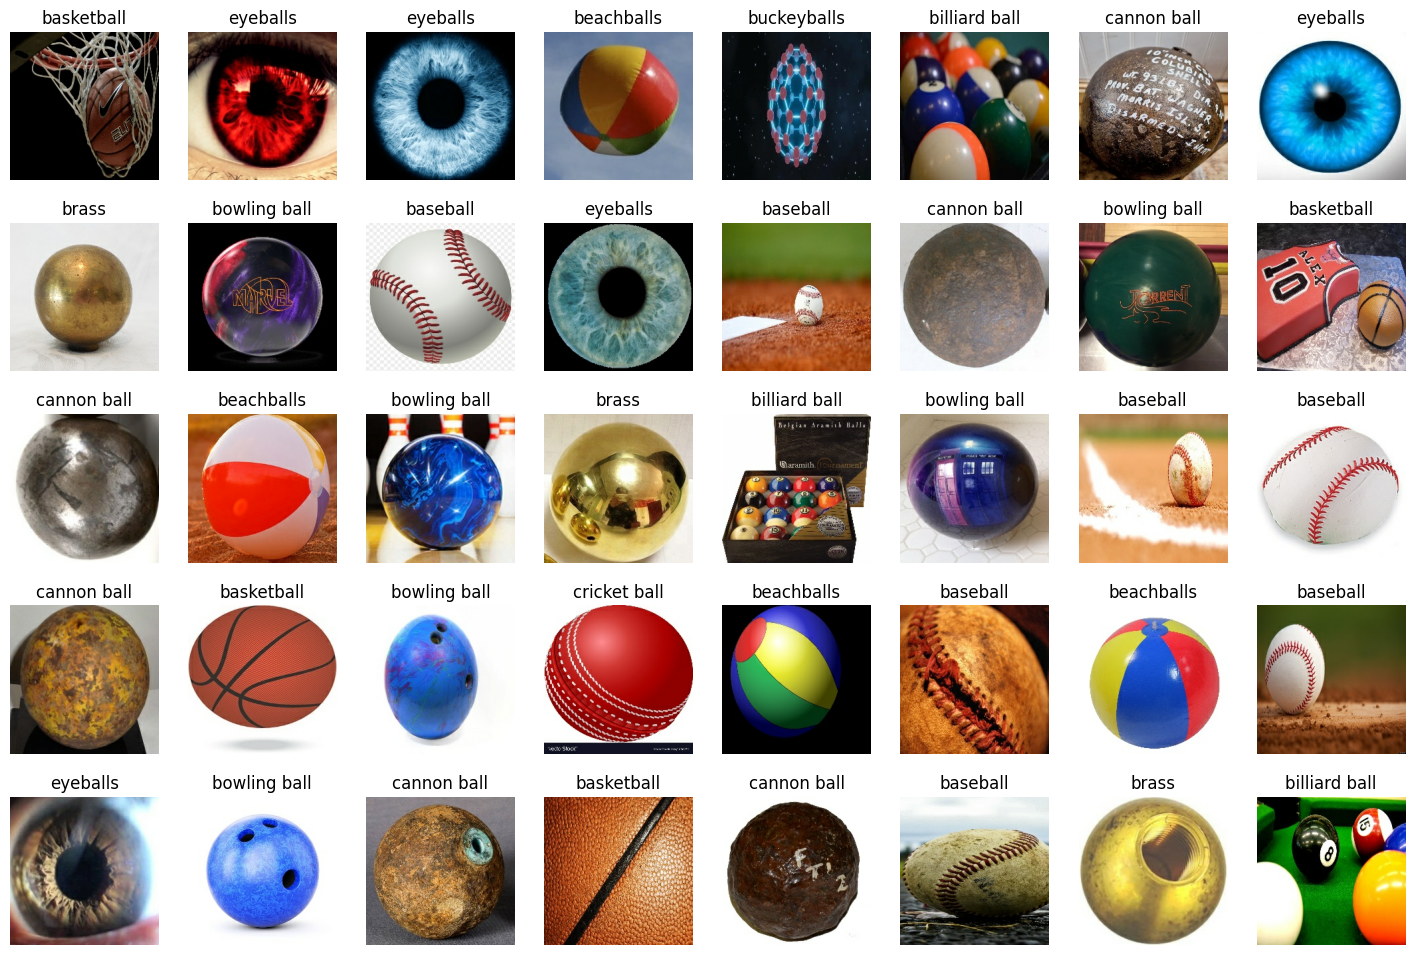

2025-11-27 14:53:52.424045: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
%run -i data_preprocessing.ipynb

In [4]:
model = cnn_model(
    inputShape=(
        datasetConfig.IMG_HEIGHT,
        datasetConfig.IMG_WIDTH,
        datasetConfig.NUM_CHANNELS,
    ),
    numClasses=datasetConfig.NUM_CLASSES,
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,868,010 (102.49 MB)

 Trainable params: 26,868,010 (102.49 MB)

 Non-trainable params: 0 (0.00 B)

None
